# Diabetes Prediction ML Pipeline
**Focus:** Handling missing medical data, Class imbalance, Sensitivity vs Specificity, and Medical Interpretability.

**Models:** Decision Tree, Random Forest, XGBoost.

**Dataset**  Pima Indians Diabetes Database


# CELL 1: Imports and Setup


In [3]:
import sys
print(sys.executable)
!{sys.executable} -m pip install kagglehub

C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 481.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/70.6 kB ? eta -:--:--
   ----------------- ---------------------- 30.7/70.6 kB 262.6 kB/s eta 0:00:01
   ---------------------------------- ----- 61.4/70.6 kB 469.7 kB/s eta 0:00:01
   ---------------------------------------- 70.6/70.6 kB 483.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/212.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/212.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/212.7 kB ? eta -:--:--
   ------------- ------------------------- 71.7/212.7 kB 563.7 kB/s eta 0:00:01
   ------------- ------------


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, make_scorer, recall_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")



# CELL 2: Data Loading (Directly from Kaggle)


In [6]:
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
csv_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(csv_path)

print(f"Successfully loaded diabetes.csv from: {csv_path}")
print(f"Dataset Shape: {df.shape}\n")
display(df.head()) 


100%|██████████████████████████████████████████████████████████████████████████████| 8.91k/8.91k [00:00<00:00, 240kB/s]

Extracting files...
Successfully loaded diabetes.csv from: C:\Users\hp\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1\diabetes.csv
Dataset Shape: (768, 9)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



# CELL 3: Exploratory Data Analysis (EDA)


Target Variable Distribution (Outcome):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Invalid Zero Values Count (Before Processing):
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


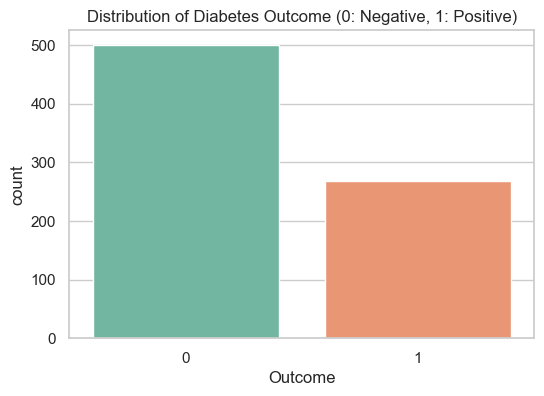

In [7]:
print("Target Variable Distribution (Outcome):")
print(df['Outcome'].value_counts(normalize=True)) 
# Indicates mild class imbalance (~65% negative, 35% positive)

# Medical Data Quirk: Check for 0s in biological metrics where 0 is physiologically impossible
features_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nInvalid Zero Values Count (Before Processing):")
for col in features_with_invalid_zeros:
    print(f"{col}: {(df[col] == 0).sum()}")

# Visualizing the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribution of Diabetes Outcome (0: Negative, 1: Positive)')
plt.show()

# CELL 4: Data Preprocessing

In [8]:
df_clean = df.copy()  # Replace 0s with NaN, then impute with the median (robust to outliers in m)edical data
df_clean[features_with_invalid_zeros] = df_clean[features_with_invalid_zeros].replace(0, np.nan)
imputer = SimpleImputer(strategy='median')
df_clean[features_with_invalid_zeros] = imputer.fit_transform(df_clean[features_with_invalid_zeros])

print("Invalid Zero Values Count (After Processing):") # Verify zeros are handled
print((df_clean[features_with_invalid_zeros] == 0).sum())

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# d. Handling Class Imbalance
# Using SMOTE (Synthetic Minority Over-sampling Technique) on training data ONLY to prevent data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"\nResampled Training Target Distribution:\n{y_train_resampled.value_counts()}")


Invalid Zero Values Count (After Processing):
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Resampled Training Target Distribution:
Outcome
0    400
1    400
Name: count, dtype: int64



# CELL 5: Model Training & Hyperparameter Tuning


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  #StratifiedKFold for cross-validation to respect class distributions

scorer = make_scorer(recall_score)# Medical Focus: Optimize for Recall (Sensitivity) to minimize False Negatives

# a. Decision Tree
print("Tuning Decision Tree...")
dt_params = {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=cv, scoring=scorer, n_jobs=-1)
dt_grid.fit(X_train_resampled, y_train_resampled)
best_dt = dt_grid.best_estimator_

# b. Random Forest
print("Tuning Random Forest...")
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 2, 4]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=cv, scoring=scorer, n_jobs=-1)
rf_grid.fit(X_train_resampled, y_train_resampled)
best_rf = rf_grid.best_estimator_

# c. XGBoost
print("Tuning XGBoost...")
xgb_params = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params, cv=cv, scoring=scorer, n_jobs=-1)
xgb_grid.fit(X_train_resampled, y_train_resampled)
best_xgb = xgb_grid.best_estimator_

print("\nBest Parameters Found:")
print(f"DT:  {dt_grid.best_params_}")
print(f"RF:  {rf_grid.best_params_}")
print(f"XGB: {xgb_grid.best_params_}")


Tuning Decision Tree...
Tuning Random Forest...
Tuning XGBoost...

Best Parameters Found:
DT:  {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
RF:  {'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 100}
XGB: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}


# CELL 6: Evaluation 

In [ ]:
models = {'Decision Tree': best_dt, 'Random Forest': best_rf, 'XGBoost': best_xgb}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate Sensitivity and Specificity
    sensitivity = tp / (tp + fn) # True Positive Rate / Recall
    specificity = tn / (tn + fp) # True Negative Rate
    
    print(f"\n================ [{name}] ================")
    print(f"Sensitivity (Recall) : {sensitivity:.3f}  (Correctly identifies diabetics)")
    print(f"Specificity          : {specificity:.3f}  (Correctly identifies healthy patients)")
    print(f"ROC-AUC Score        : {roc_auc_score(y_test, y_prob):.3f}")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))



# CELL 7: Medical Interpretability


In [ ]:
# Extracting feature importances
importances_rf = best_rf.feature_importances_
importances_xgb = best_xgb.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
indices_xgb = np.argsort(importances_xgb)[::-1]

# Visualizing Feature Importance
plt.figure(figsize=(14, 5))

# Random Forest Importances
plt.subplot(1, 2, 1)
plt.title("Random Forest - Feature Importances")
plt.bar(range(X.shape[1]), importances_rf[indices_rf], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices_rf], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.ylabel('Importance Score')

# XGBoost Importances
plt.subplot(1, 2, 2)
plt.title("XGBoost - Feature Importances")
plt.bar(range(X.shape[1]), importances_xgb[indices_xgb], align="center", color='lightcoral', edgecolor='black')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices_xgb], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nMedical Context Insight:")
print("- Glucose & BMI consistently rank as top predictors. This aligns perfectly with endocrinology, as elevated blood sugar and obesity are the primary risk factors for Type 2 Diabetes.")
